In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
from PIL.ImageColor import colormap
from scipy import stats

from ipynb.fs.defs.functions import top_bottom_split_triple, find_outliers_iqr

In [2]:
# Einlesen
df = pd.read_csv("../data/processed/master_2024.csv", sep=",", encoding="UTF-8")
df.columns

Index(['Name', 'Typ 1', 'Typ 2', 'ROR', 'erz. Hilfen pro 10000',
       '35a Hilfen pro 10000', 'Überörtlicher Träger', 'Bevölkerung 6 bis 20',
       'Anteil Kinder a.d. Gesamtbev.', 'SGB II-Quote', 'Kinderarztdichte',
       'KJP-Dichte', 'Bildungsindex', 'Bevölkerungsdichte', 'Typ'],
      dtype='object')

In [3]:
df = df[df["Name"] != "Aachen"]

In [8]:
def summary_stats(s):
    desc = s.describe()
    iqr = desc["75%"] - desc["25%"]
    span = desc["max"] - desc["min"]
    cv = desc["std"] / desc["mean"]

    return pd.Series({
        "n": desc["count"],
        "mean": desc["mean"],
        "median": desc["50%"],
        "std": desc["std"],
        "IQR": iqr,
        "span": span,
        "IQR/span": iqr / span,
        "CV": cv
    })

summary_by_type = (
    df
    .groupby("Typ 1")["35a Hilfen pro 10000"]
    .apply(summary_stats)
    .round(3))

print(summary_by_type)

Typ 1                     
Großer Kreis      n            22.000
                  mean        182.636
                  median      181.500
                  std          65.492
                  IQR          93.250
                  span        232.000
                  IQR/span      0.402
                  CV            0.359
Kleiner Kreis     n             8.000
                  mean        174.125
                  median      168.000
                  std          58.796
                  IQR          81.500
                  span        155.000
                  IQR/span      0.526
                  CV            0.338
Kreisfreie Stadt  n            22.000
                  mean        180.591
                  median      165.000
                  std          69.152
                  IQR          71.000
                  span        257.000
                  IQR/span      0.276
                  CV            0.383
Name: 35a Hilfen pro 10000, dtype: float64


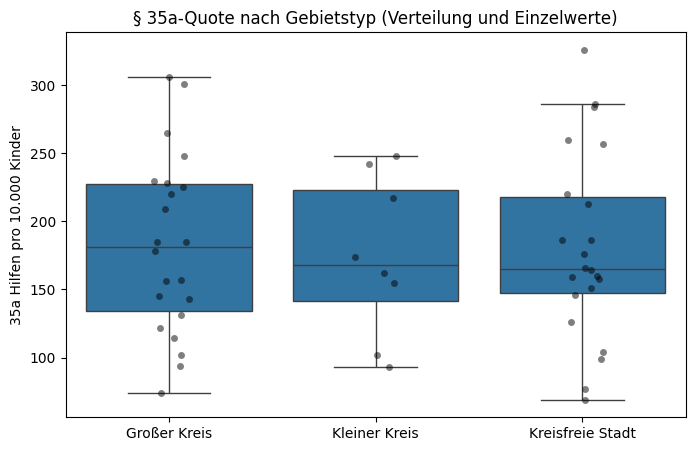

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x="Typ 1",
    y="35a Hilfen pro 10000",
    showfliers=False
)
sns.stripplot(
    data=df,
    x="Typ 1",
    y="35a Hilfen pro 10000",
    color="black",
    alpha=0.5,
    jitter=True
)
plt.title("§ 35a-Quote nach Gebietstyp (Verteilung und Einzelwerte)")
plt.ylabel("35a Hilfen pro 10.000 Kinder")
plt.xlabel("")
plt.show()
